# EDA-2 — Signal Distributions (X)  [v1.6 — exposure-aware]

Characterise every candidate signal under **two population scopes** before it enters EDA-3.

This notebook answers: *under what exposure regime is this signal analytically viable?*

The minutes filter is not a data cleaning step — it changes the estimand.  
EDA-2 must characterise how each signal behaves under both scopes before EDA-3 runs any joint analysis.

**Scope:**
- Q2.1 — Dual-scope marginal distributions (conditioned + active)
- Q2.2 — Structural zero governance (natural vs exposure-induced zeros)
- Q2.3 — Exposure sensitivity classification
- Q2.4 — Preferred population assignment
- Q2.5 — Near-zero variance gate (conditioned scope)
- Q2.6 — Block variance compression (conditioned scope)
- Summary — Exposure-aware signal registry (11 required fields for EDA-3)

**Traceability:** implements `EDA_DESIGN.md` v1.6 — EDA-2 section.  
**Registry output:** `signals/eda/findings/eda_02_signal_registry.csv`

## Population scopes

Two population scopes are defined here and used throughout this notebook and EDA-3.

| Scope | Filter | Purpose |
|---|---|---|
| `exposure_conditioned` | `minutes >= 60` | Players who started and played meaningful minutes |
| `active_population` | `minutes > 0` | All players who appeared, including cameos |

These are not interchangeable. The conditioned scope filters exposure-induced structural zeros.  
The active scope retains them. The difference in signal behaviour between the two scopes is  
the primary diagnostic this notebook produces.

GW range: **GW 6–33** (EDA-1 gate decision — GW 34 excluded, BGW rows absent by construction).

## Notebook Setup

Imports, constants, signal family map, and output paths.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from dal.curated.player_gameweek_spine import build_player_gameweek_spine
from signals.eda.notebooks._signal_distribution_helpers import (
    POSITION_MAP,
    POSITIONS,
    SIGNAL_FAMILY,
    assign_preferred_population,
    build_exposure_aware_registry,
    compute_block_variance_scoped,
    compute_dual_scope_summary,
    compute_exposure_sensitivity,
    compute_variance_flags_scoped,
    compute_zero_rate_comparison,
    split_candidate_signals,
)

DB_PATH      = Path.home() / ".fpl" / "fpl.db"
FINDINGS_DIR = Path("../findings")

# --- GW range (from EDA-1 gate decisions) ---
GW_MIN       = 6
GW_UPPER     = 33
ACTIVITY_MIN = 60   # exposure_conditioned threshold

# --- Output paths ---
DUAL_SCOPE_SUMMARY_CSV = FINDINGS_DIR / "eda_02_signal_summary_dual_scope.csv"
ZERO_DELTA_HEATMAP     = FINDINGS_DIR / "eda_02_zero_rate_delta_heatmap.png"
REGISTRY_CSV           = FINDINGS_DIR / "eda_02_signal_registry.csv"

BLOCK_MIN_N = 30

# All candidate signals — family assigned in SIGNAL_FAMILY map in helpers
CANDIDATE_SIGNALS = [
    # attacking
    "goals_scored", "assists", "xg", "xa", "xgi",
    # ICT composite + components
    "bonus", "bps", "ict_index", "influence", "creativity", "threat",
    # defensive
    "clean_sheets", "goals_conceded", "saves", "xgc",
    "penalties_saved", "own_goals",
    # exposure / availability
    "minutes", "starts",
    # fixture context
    "fdr_avg", "fdr_min", "fdr_max", "was_home", "is_dgw", "fixture_count",
    # market / ownership
    "transfers_in", "transfers_out", "transfers_balance",
    "ownership_count", "purchase_price",
    # discipline
    "yellow_cards", "red_cards", "penalties_missed", "in_dreamteam",
]


def print_header(title: str) -> None:
    print("=" * 88)
    print(title)
    print("=" * 88)


pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Setup complete.")
print(f"SIGNAL_FAMILY entries: {len(SIGNAL_FAMILY)}")
families = pd.Series(SIGNAL_FAMILY).value_counts()
print(families.to_string())

Setup complete.
SIGNAL_FAMILY entries: 35
fixture       6
market        5
defensive     5
form          5
discipline    5
creativity    4
attacking     3
exposure      2


## Load Inputs

**What this cell does:** Loads the spine, builds both population scopes, confirms coverage, and inventories candidate signals against available columns.

In [2]:
spine_all = build_player_gameweek_spine(DB_PATH)

spine_gw = spine_all[
    spine_all["gw"].between(GW_MIN, GW_UPPER)
    & spine_all["total_points"].notna()
].copy()

# Two population scopes — both used throughout this notebook
state_conditioned = spine_gw[spine_gw["minutes"] >= ACTIVITY_MIN].copy()
state_active      = spine_gw[spine_gw["minutes"] > 0].copy()

assert len(state_conditioned) > 0, "Empty conditioned population"
assert len(state_active) > 0,      "Empty active population"

# Inventory candidate signals against conditioned scope columns
available, missing, numeric_signals, categorical_signals = split_candidate_signals(
    state_conditioned, CANDIDATE_SIGNALS
)

print(f"GW range:     {GW_MIN}–{GW_UPPER}")
print(f"exposure_conditioned (minutes >= {ACTIVITY_MIN}): {len(state_conditioned):,} rows")
print(f"active_population    (minutes > 0):              {len(state_active):,} rows")
print(f"Additional rows in active vs conditioned:         {len(state_active) - len(state_conditioned):,}")
print()

print("Coverage by position × scope:")
for scope_name, df in [("conditioned", state_conditioned), ("active", state_active)]:
    row = {POSITION_MAP[p]: len(df[df["position_code"] == p]) for p in POSITIONS}
    print(f"  {scope_name:<14}: " + "  ".join(f"{k}={v:,}" for k, v in row.items()))

print(f"\nCandidate signals: {len(CANDIDATE_SIGNALS)}")
print(f"  Available: {len(available)}")
print(f"  Numeric:   {len(numeric_signals)}")
print(f"  Missing:   {missing or 'none'}")

if missing:
    print(f"\nWARNING — missing signals will not appear in registry: {missing}")

GW range:     6–33
exposure_conditioned (minutes >= 60): 5,736 rows
active_population    (minutes > 0):              8,410 rows
Additional rows in active vs conditioned:         2,674

Coverage by position × scope:
  conditioned   : GK=553  DEF=2,214  MID=2,412  FWD=557
  active        : GK=561  DEF=2,882  MID=3,918  FWD=1,049

Candidate signals: 34
  Available: 34
  Numeric:   34
  Missing:   none


## Q2.1 — Dual-scope marginal distributions

**Question:** What does each signal look like under each population scope, and where do distributions differ materially?

**What this cell does:** Computes mean, median, std, zero_rate, p90, skew for every signal-position pair under both scopes. Saves the dual-scope summary CSV. The zero_rate column is the input to Q2.2.

In [3]:
print_header("Q2.1 — Dual-scope marginal distributions")

dual_summary = compute_dual_scope_summary(
    state_conditioned=state_conditioned,
    state_active=state_active,
    numeric_signals=numeric_signals,
    positions=POSITIONS,
)

FINDINGS_DIR.mkdir(parents=True, exist_ok=True)
dual_summary.to_csv(DUAL_SCOPE_SUMMARY_CSV, index=False)
print(f"Saved: {DUAL_SCOPE_SUMMARY_CSV}  ({len(dual_summary)} rows)")

# Side-by-side zero_rate comparison — the first diagnostic of scope sensitivity
zero_rate_wide = dual_summary.pivot_table(
    index=["signal", "position", "signal_family"],
    columns="scope",
    values=["zero_rate", "n", "std"],
).round(3)
zero_rate_wide.columns = ["_".join(c) for c in zero_rate_wide.columns]
zero_rate_wide = zero_rate_wide.reset_index()

print("\nzero_rate by scope (sorted by active zero_rate descending):")
display(
    zero_rate_wide[["signal", "position", "signal_family",
                    "zero_rate_conditioned", "zero_rate_active",
                    "n_conditioned", "n_active"]]
    .sort_values("zero_rate_active", ascending=False)
    .reset_index(drop=True)
)

print("\nStd by scope (spot-check distribution width changes):")
display(
    zero_rate_wide[["signal", "position", "signal_family",
                    "std_conditioned", "std_active"]]
    .sort_values(["signal", "position"])
    .reset_index(drop=True)
)

Q2.1 — Dual-scope marginal distributions
Saved: ../findings/eda_02_signal_summary_dual_scope.csv  (272 rows)

zero_rate by scope (sorted by active zero_rate descending):


,signal,position,signal_family,zero_rate_conditioned,zero_rate_active,n_conditioned,n_active
0,penalties_saved,MID,defensive,1.0,1.0,2412.0,3918.0
1,saves,DEF,defensive,1.0,1.0,2214.0,2882.0
2,red_cards,GK,discipline,1.0,1.0,553.0,561.0
3,goals_scored,GK,attacking,1.0,1.0,553.0,561.0
4,in_dreamteam,FWD,discipline,1.0,1.0,557.0,1049.0
...,...,...,...,...,...,...,...
131,transfers_in,GK,market,0.0,0.0,553.0,561.0
132,purchase_price,FWD,market,0.0,0.0,557.0,1049.0
133,transfers_out,GK,market,0.0,0.0,553.0,561.0
134,fdr_min,FWD,fixture,0.0,0.0,557.0,1049.0



Std by scope (spot-check distribution width changes):


,signal,position,signal_family,std_conditioned,std_active
0,assists,DEF,creativity,0.269,0.249
1,assists,FWD,creativity,0.353,0.288
2,assists,GK,creativity,0.060,0.060
3,assists,MID,creativity,0.389,0.338
4,bonus,DEF,form,0.676,0.600
...,...,...,...,...,...
131,xgi,MID,creativity,0.286,0.257
132,yellow_cards,DEF,discipline,0.374,0.355
133,yellow_cards,FWD,discipline,0.303,0.277
134,yellow_cards,GK,discipline,0.253,0.252


## Q2.2 — Structural zero governance

**Question:** Are the zeros in each signal natural (player was active, signal was genuinely zero) or structural (player had minimal exposure, zero reflects non-participation)?

**What this cell does:** Computes `zero_rate_delta = zero_rate_active − zero_rate_conditioned`. A large delta means the active population accumulates structural zeros from low-exposure records. Classifies each signal-position pair as `structural_zero_risk`: low / moderate / high. Produces the delta heatmap for visual inspection.

A large delta is the primary indicator that a signal's preferred population is `exposure_conditioned`.

Q2.2 — Structural zero governance
Structural zero risk classifications:
structural_zero_risk
low         83
high        38
moderate    15

High structural zero risk (delta >= 0.20 or conditioned >= 0.90):


,signal,position,zero_rate_conditioned,zero_rate_active,zero_rate_delta,structural_zero_risk
0,starts,FWD,0.0036,0.4214,0.4178,high
1,starts,MID,0.0075,0.3270,0.3195,high
2,xa,FWD,0.2208,0.4261,0.2053,high
3,assists,DEF,0.9277,0.9382,0.0105,high
4,goals_scored,DEF,0.9580,0.9650,0.0070,high
5,penalties_missed,FWD,0.9874,0.9933,0.0059,high
6,is_dgw,MID,0.9809,0.9837,0.0028,high
7,is_dgw,DEF,0.9828,0.9844,0.0016,high
8,is_dgw,FWD,0.9803,0.9819,0.0016,high
9,own_goals,DEF,0.9914,0.9927,0.0013,high



Moderate structural zero risk (delta 0.10–0.20):


,signal,position,zero_rate_conditioned,zero_rate_active,zero_rate_delta,structural_zero_risk
0,starts,DEF,0.0036,0.1908,0.1872,moderate
1,xg,FWD,0.1436,0.3213,0.1777,moderate
2,xgi,FWD,0.0413,0.1983,0.1570,moderate
3,clean_sheets,FWD,0.6858,0.8332,0.1474,moderate
4,xa,MID,0.0456,0.1907,0.1451,moderate
5,goals_conceded,FWD,0.3034,0.4461,0.1427,moderate
6,xg,MID,0.2981,0.4357,0.1376,moderate
7,goals_conceded,MID,0.2910,0.4239,0.1329,moderate
8,threat,FWD,0.0287,0.1602,0.1315,moderate
9,threat,MID,0.1434,0.2637,0.1203,moderate


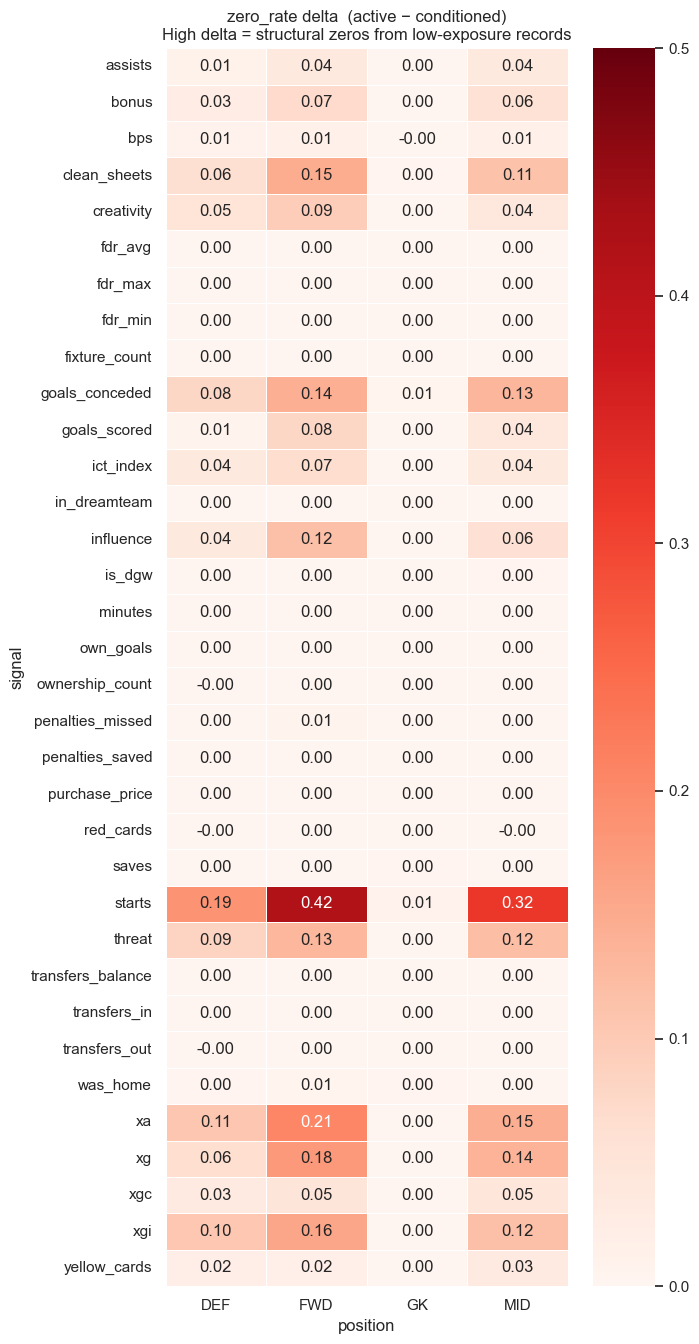

Saved: ../findings/eda_02_zero_rate_delta_heatmap.png


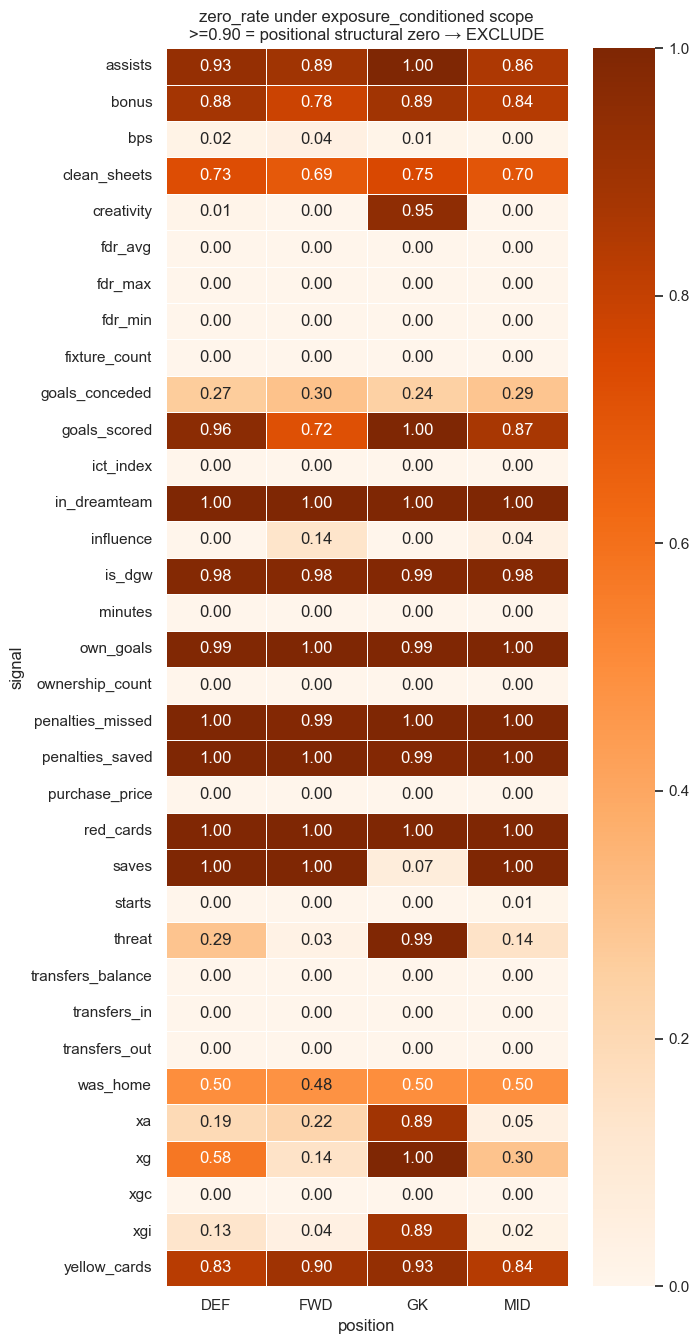

In [4]:
print_header("Q2.2 — Structural zero governance")

zero_comparison = compute_zero_rate_comparison(dual_summary)

print("Structural zero risk classifications:")
print(zero_comparison["structural_zero_risk"].value_counts().to_string())
print()

print("High structural zero risk (delta >= 0.20 or conditioned >= 0.90):")
high_risk = zero_comparison[zero_comparison["structural_zero_risk"] == "high"]
display(
    high_risk[["signal", "position", "zero_rate_conditioned",
               "zero_rate_active", "zero_rate_delta", "structural_zero_risk"]]
    .reset_index(drop=True)
)

print("\nModerate structural zero risk (delta 0.10–0.20):")
mod_risk = zero_comparison[zero_comparison["structural_zero_risk"] == "moderate"]
display(
    mod_risk[["signal", "position", "zero_rate_conditioned",
              "zero_rate_active", "zero_rate_delta", "structural_zero_risk"]]
    .reset_index(drop=True)
)

# Heatmap: zero_rate_delta
pivot_delta = zero_comparison.pivot(
    index="signal", columns="position", values="zero_rate_delta"
)
fig, ax = plt.subplots(figsize=(7, max(6, len(pivot_delta) * 0.40)))
sns.heatmap(
    pivot_delta, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=0.5, ax=ax,
    linewidths=0.5,
)
ax.set_title("zero_rate delta  (active − conditioned)\nHigh delta = structural zeros from low-exposure records")
plt.tight_layout()
plt.savefig(ZERO_DELTA_HEATMAP, dpi=120)
plt.show()
print(f"Saved: {ZERO_DELTA_HEATMAP}")

# Also show conditioned zero_rate for context
pivot_cond = zero_comparison.pivot(
    index="signal", columns="position", values="zero_rate_conditioned"
)
fig2, ax2 = plt.subplots(figsize=(7, max(6, len(pivot_cond) * 0.40)))
sns.heatmap(
    pivot_cond, annot=True, fmt=".2f",
    cmap="Oranges", vmin=0, vmax=1.0, ax=ax2,
    linewidths=0.5,
)
ax2.set_title("zero_rate under exposure_conditioned scope\n>=0.90 = positional structural zero → EXCLUDE")
plt.tight_layout()
plt.show()

## Q2.3 — Exposure sensitivity classification

**Question:** How much does the signal's rank structure change when we move from the conditioned to the active population?

**What this cell does:** Computes three metrics per signal-position pair:
- `rank_order_stability` — Spearman rho between player-mean signal ranks under each scope (on overlap players)
- `variance_ratio` — var(active) / var(conditioned)
- `support_collapse` — effective non-zero records: conditioned / active

Classifies each pair as one of: `exposure_robust` | `exposure_sensitive` | `exposure_degenerate` | `exposure_proxy`

In [5]:
print_header("Q2.3 — Exposure sensitivity classification")

exp_sens = compute_exposure_sensitivity(
    state_conditioned=state_conditioned,
    state_active=state_active,
    numeric_signals=numeric_signals,
    positions=POSITIONS,
    zero_comparison=zero_comparison,
    min_n=BLOCK_MIN_N,
)

print("Sensitivity counts:")
print(exp_sens["exposure_sensitivity"].value_counts().to_string())
print()

print("By signal family:")
print(
    exp_sens.groupby(["signal_family", "exposure_sensitivity"])
    .size()
    .unstack(fill_value=0)
    .to_string()
)
print()

print("exposure_degenerate pairs (signal collapses under active population):")
degen = exp_sens[exp_sens["exposure_sensitivity"] == "exposure_degenerate"]
display(degen[["signal", "position", "signal_family",
               "rank_order_stability", "variance_ratio",
               "support_collapse"]].reset_index(drop=True))

print("\nexposure_sensitive pairs (rank structure shifts meaningfully):")
sensitive = exp_sens[exp_sens["exposure_sensitivity"] == "exposure_sensitive"]
display(sensitive[["signal", "position", "signal_family",
                   "rank_order_stability", "variance_ratio",
                   "support_collapse"]].reset_index(drop=True))

print("\nexposure_proxy pairs (signals encoding participation probability):")
proxy = exp_sens[exp_sens["exposure_sensitivity"] == "exposure_proxy"]
display(proxy[["signal", "position", "signal_family",
               "rank_order_stability", "variance_ratio"]].reset_index(drop=True))

print("\nAll pairs (full table):")
display(
    exp_sens[["signal", "position", "signal_family",
              "rank_order_stability", "variance_ratio",
              "support_collapse", "exposure_sensitivity"]]
    .sort_values(["exposure_sensitivity", "signal", "position"])
    .reset_index(drop=True)
)

Q2.3 — Exposure sensitivity classification
Sensitivity counts:
exposure_sensitivity
exposure_robust        49
exposure_sensitive     44
exposure_proxy         28
exposure_degenerate    15

By signal family:
exposure_sensitivity  exposure_degenerate  exposure_proxy  exposure_robust  exposure_sensitive
signal_family                                                                                 
attacking                               1               0                8                   3
creativity                              0               0               13                   3
defensive                               6               0                5                   9
discipline                              8               0                8                   4
exposure                                0               8                0                   0
fixture                                 0               0                8                  16
form                             

,signal,position,signal_family,rank_order_stability,variance_ratio,support_collapse
0,goals_scored,GK,attacking,NaN,NaN,NaN
1,saves,DEF,defensive,NaN,NaN,NaN
2,saves,MID,defensive,NaN,NaN,NaN
3,saves,FWD,defensive,NaN,NaN,NaN
4,penalties_saved,DEF,defensive,NaN,NaN,NaN
5,penalties_saved,MID,defensive,NaN,NaN,NaN
6,penalties_saved,FWD,defensive,NaN,NaN,NaN
7,red_cards,GK,discipline,NaN,NaN,NaN
8,red_cards,FWD,discipline,NaN,NaN,NaN
9,penalties_missed,GK,discipline,NaN,NaN,NaN



exposure_sensitive pairs (rank structure shifts meaningfully):


,signal,position,signal_family,rank_order_stability,variance_ratio,support_collapse
0,goals_scored,FWD,attacking,0.786,0.726,0.745
1,assists,FWD,creativity,0.837,0.663,0.789
2,xg,FWD,attacking,0.619,0.731,0.670
3,xgi,FWD,creativity,0.597,0.758,0.635
4,bps,DEF,form,0.784,0.986,0.804
5,bps,MID,form,0.797,0.978,0.635
6,bps,FWD,form,0.703,0.765,0.549
7,ict_index,DEF,form,0.840,1.053,0.796
8,ict_index,MID,form,0.847,0.934,0.639
9,ict_index,FWD,form,0.704,0.845,0.570



exposure_proxy pairs (signals encoding participation probability):


,signal,position,signal_family,rank_order_stability,variance_ratio
0,minutes,GK,exposure,0.837,1.374
1,minutes,DEF,exposure,0.539,6.844
2,minutes,MID,exposure,0.739,6.965
3,minutes,FWD,exposure,0.504,5.216
4,starts,GK,exposure,0.893,1.623
5,starts,DEF,exposure,0.321,9.662
6,starts,MID,exposure,0.266,13.220
7,starts,FWD,exposure,0.313,13.237
8,transfers_in,GK,market,0.999,0.990
9,transfers_in,DEF,market,0.982,0.827



All pairs (full table):


,signal,position,signal_family,rank_order_stability,variance_ratio,support_collapse,exposure_sensitivity
0,goals_scored,GK,attacking,NaN,NaN,NaN,exposure_degenerate
1,in_dreamteam,DEF,discipline,NaN,NaN,NaN,exposure_degenerate
2,in_dreamteam,FWD,discipline,NaN,NaN,NaN,exposure_degenerate
3,in_dreamteam,GK,discipline,NaN,NaN,NaN,exposure_degenerate
4,in_dreamteam,MID,discipline,NaN,NaN,NaN,exposure_degenerate
...,...,...,...,...,...,...,...
131,xgc,FWD,defensive,0.660,0.974,0.558,exposure_sensitive
132,xgc,MID,defensive,0.732,1.083,0.645,exposure_sensitive
133,xgi,FWD,creativity,0.597,0.758,0.635,exposure_sensitive
134,yellow_cards,DEF,discipline,0.826,0.903,0.871,exposure_sensitive


## Q2.4 — Preferred population assignment

**Question:** Which population scope should EDA-3 use as canonical for each signal-position pair?

**What this cell does:** Applies the documented assignment rules to produce `preferred_population` ∈ {`exposure_conditioned`, `active_population`, `both`} for each pair.

Assignment rules (priority order):
1. `exposure_degenerate` → `exposure_conditioned`
2. `exposure_proxy` (family: exposure / market) → `active_population`
3. family (attacking / creativity) + zero_risk high → `exposure_conditioned`
4. family (attacking / creativity) + sensitivity sensitive → `exposure_conditioned`
5. otherwise → `both`

This output is the **primary contract EDA-3 consumes**. EDA-3 must not blindly run every signal under every scope — it reads this field and uses it.

In [6]:
print_header("Q2.4 — Preferred population assignment")

preferred_df = assign_preferred_population(
    exp_sens=exp_sens,
    zero_comparison=zero_comparison,
)

print("Preferred population counts:")
print(preferred_df["preferred_population"].value_counts().to_string())
print()

print("By signal family × preferred_population:")
print(
    preferred_df.groupby(["signal_family", "preferred_population"])
    .size()
    .unstack(fill_value=0)
    .to_string()
)
print()

print("exposure_conditioned assignments:")
ec = preferred_df[preferred_df["preferred_population"] == "exposure_conditioned"]
display(
    ec[["signal", "position", "signal_family", "exposure_sensitivity",
        "structural_zero_risk", "preferred_population"]]
    .reset_index(drop=True)
)

print("\nactive_population assignments:")
ap = preferred_df[preferred_df["preferred_population"] == "active_population"]
display(
    ap[["signal", "position", "signal_family", "exposure_sensitivity",
        "structural_zero_risk", "preferred_population"]]
    .reset_index(drop=True)
)

print("\nCheck: any unexpected preferred_population assignments?")
print("Review the 'both' assignments for attacking/creativity signals — these may warrant override.")
both = preferred_df[
    (preferred_df["preferred_population"] == "both") &
    (preferred_df["signal_family"].isin(["attacking", "creativity"]))
]
if both.empty:
    print("  None — all attacking/creativity signals assigned to exposure_conditioned as expected.")
else:
    display(both[["signal", "position", "signal_family", "exposure_sensitivity",
                  "structural_zero_risk"]].reset_index(drop=True))

Q2.4 — Preferred population assignment
Preferred population counts:
preferred_population
both                    80
exposure_conditioned    28
active_population       28

By signal family × preferred_population:
preferred_population  active_population  both  exposure_conditioned
signal_family                                                      
attacking                             0     5                     7
creativity                            0     9                     7
defensive                             0    14                     6
discipline                            0    12                     8
exposure                              8     0                     0
fixture                               0    24                     0
form                                  0    16                     0
market                               20     0                     0

exposure_conditioned assignments:


,signal,position,signal_family,exposure_sensitivity,structural_zero_risk,preferred_population
0,goals_scored,GK,attacking,exposure_degenerate,high,exposure_conditioned
1,goals_scored,DEF,attacking,exposure_robust,high,exposure_conditioned
2,goals_scored,FWD,attacking,exposure_sensitive,low,exposure_conditioned
3,assists,GK,creativity,exposure_robust,high,exposure_conditioned
4,assists,DEF,creativity,exposure_robust,high,exposure_conditioned
5,assists,FWD,creativity,exposure_sensitive,low,exposure_conditioned
6,xg,GK,attacking,exposure_robust,high,exposure_conditioned
7,xg,FWD,attacking,exposure_sensitive,moderate,exposure_conditioned
8,xa,FWD,creativity,exposure_robust,high,exposure_conditioned
9,xgi,FWD,creativity,exposure_sensitive,moderate,exposure_conditioned



active_population assignments:


,signal,position,signal_family,exposure_sensitivity,structural_zero_risk,preferred_population
0,minutes,GK,exposure,exposure_proxy,low,active_population
1,minutes,DEF,exposure,exposure_proxy,low,active_population
2,minutes,MID,exposure,exposure_proxy,low,active_population
3,minutes,FWD,exposure,exposure_proxy,low,active_population
4,starts,GK,exposure,exposure_proxy,low,active_population
5,starts,DEF,exposure,exposure_proxy,moderate,active_population
6,starts,MID,exposure,exposure_proxy,high,active_population
7,starts,FWD,exposure,exposure_proxy,high,active_population
8,transfers_in,GK,market,exposure_proxy,low,active_population
9,transfers_in,DEF,market,exposure_proxy,low,active_population



Check: any unexpected preferred_population assignments?
Review the 'both' assignments for attacking/creativity signals — these may warrant override.


,signal,position,signal_family,exposure_sensitivity,structural_zero_risk
0,goals_scored,MID,attacking,exposure_robust,low
1,assists,MID,creativity,exposure_robust,low
2,xg,DEF,attacking,exposure_robust,low
3,xg,MID,attacking,exposure_robust,moderate
4,xa,GK,creativity,exposure_robust,low
5,xa,DEF,creativity,exposure_robust,moderate
6,xa,MID,creativity,exposure_robust,moderate
7,xgi,GK,creativity,exposure_robust,low
8,xgi,DEF,creativity,exposure_robust,moderate
9,xgi,MID,creativity,exposure_robust,moderate


## Q2.5 — Near-zero variance gate (conditioned scope)

**Question:** Which signal-position pairs have near-zero variance under the conditioned scope and cannot carry ranking information?

**What this cell does:** Applies the variance gate to the conditioned scope only (the canonical analytical population). Pairs failing this gate are excluded from the EDA-3 registry. IQR = 0 with std > 0 is `NEAR_CONSTANT` (exclusion). std = 0 is `CONSTANT` (exclusion). CV < 0.10 is `LOW_VARIANCE` (flag only, not excluded).

In [7]:
print_header("Q2.5 — Near-zero variance gate (conditioned scope)")

variance_flags = compute_variance_flags_scoped(dual_summary, scope="conditioned")

print("Variance annotation counts (conditioned scope):")
print(variance_flags["annotation"].value_counts().to_string())
print()

print("Non-OK annotations:")
non_ok = variance_flags[variance_flags["annotation"] != "OK"]
display(
    non_ok[["signal", "position", "std", "iqr", "cv", "annotation"]]
    .sort_values(["annotation", "signal", "position"])
    .reset_index(drop=True)
)

print("\nOK pairs (will enter EDA-3 unless excluded by Q2.2):")
ok_pairs = variance_flags[variance_flags["annotation"] == "OK"]
print(f"  {len(ok_pairs)} signal-position pairs")

Q2.5 — Near-zero variance gate (conditioned scope)
Variance annotation counts (conditioned scope):
annotation
OK               67
NEAR_CONSTANT    54
CONSTANT         15

Non-OK annotations:


,signal,position,std,iqr,cv,annotation
0,goals_scored,GK,0.000000,0.0,NaN,CONSTANT
1,in_dreamteam,DEF,0.000000,0.0,NaN,CONSTANT
2,in_dreamteam,FWD,0.000000,0.0,NaN,CONSTANT
3,in_dreamteam,GK,0.000000,0.0,NaN,CONSTANT
4,in_dreamteam,MID,0.000000,0.0,NaN,CONSTANT
...,...,...,...,...,...,...
64,xgi,GK,0.010992,0.0,5.6281,NEAR_CONSTANT
65,yellow_cards,DEF,0.373970,0.0,2.2257,NEAR_CONSTANT
66,yellow_cards,FWD,0.303359,0.0,2.9644,NEAR_CONSTANT
67,yellow_cards,GK,0.253200,0.0,3.6847,NEAR_CONSTANT



OK pairs (will enter EDA-3 unless excluded by Q2.2):
  67 signal-position pairs


## Q2.6 — Block variance compression (conditioned scope)

**Question:** Does signal variance compress or expand meaningfully across season phases, and is the signal less discriminating in the mid-season reference block?

**What this cell does:** Computes std per signal-position-block under the conditioned scope only. Records % change vs mid block. Classifies each pair as `stable` / `compressing` / `expanding`. This is a descriptive flag — it does not exclude signals but constrains interpretation in lens studies.

In [8]:
print_header("Q2.6 — Block variance compression (conditioned scope)")

block_variance, block_pivot = compute_block_variance_scoped(
    state_conditioned=state_conditioned,
    numeric_signals=numeric_signals,
    positions=POSITIONS,
    gw_min=GW_MIN,
    gw_upper=GW_UPPER,
    min_n=BLOCK_MIN_N,
)

# Classify stability in pivot
def _classify_block_stability(row):
    ev = row.get("early_vs_mid_pct")
    lv = row.get("late_vs_mid_pct")
    import numpy as np
    if (ev is None or (hasattr(ev, '__float__') and __import__('math').isnan(float(ev)))) and \
       (lv is None or (hasattr(lv, '__float__') and __import__('math').isnan(float(lv)))):
        return "unknown"
    if lv is not None and not __import__('math').isnan(float(lv)) and float(lv) < -30:
        return "compressing"
    if (ev is not None and not __import__('math').isnan(float(ev)) and abs(float(ev)) > 30) or \
       (lv is not None and not __import__('math').isnan(float(lv)) and float(lv) > 30):
        return "expanding"
    return "stable"

import math
block_pivot["gw_block_variance_stability"] = block_pivot.apply(
    lambda r: "compressing" if (
        not math.isnan(float(r.get("late_vs_mid_pct", float("nan")) or float("nan")))
        and float(r.get("late_vs_mid_pct", 0)) < -30
    ) else (
        "expanding" if (
            (not math.isnan(float(r.get("early_vs_mid_pct", float("nan")) or float("nan")))
             and abs(float(r.get("early_vs_mid_pct", 0))) > 30)
            or
            (not math.isnan(float(r.get("late_vs_mid_pct", float("nan")) or float("nan")))
             and float(r.get("late_vs_mid_pct", 0)) > 30)
        ) else "stable"
    ),
    axis=1,
)

print("Block variance stability counts:")
print(block_pivot["gw_block_variance_stability"].value_counts().to_string())
print()

print("Compressing signals (late block std drops >30% vs mid):")
compressing = block_pivot[block_pivot["gw_block_variance_stability"] == "compressing"]
if compressing.empty:
    print("  None")
else:
    display(
        compressing[["signal", "position", "early", "mid", "late",
                     "early_vs_mid_pct", "late_vs_mid_pct",
                     "gw_block_variance_stability"]]
        .reset_index(drop=True)
    )

print("\n% change vs mid (all pairs, sorted by late_vs_mid_pct):")
display(
    block_pivot[["signal", "position", "early_vs_mid_pct",
                 "late_vs_mid_pct", "gw_block_variance_stability"]]
    .sort_values("late_vs_mid_pct")
    .reset_index(drop=True)
)

Q2.6 — Block variance compression (conditioned scope)
Block variance stability counts:
gw_block_variance_stability
stable         108
expanding       22
compressing      6

Compressing signals (late block std drops >30% vs mid):


block,signal,position,early,mid,late,early_vs_mid_pct,late_vs_mid_pct,gw_block_variance_stability
0,assists,GK,0.074536,0.071067,0.000000,4.880885,-100.000000,compressing
1,own_goals,FWD,0.000000,0.069505,0.000000,-100.000000,-100.000000,compressing
2,penalties_missed,MID,0.050220,0.048622,0.000000,3.287675,-100.000000,compressing
3,transfers_balance,MID,140383.312007,166635.922478,105901.043638,-15.754472,-36.447651,compressing
4,transfers_in,MID,120816.663035,158399.044526,78355.086208,-23.726394,-50.533107,compressing
5,transfers_out,FWD,171313.003957,164730.644621,97922.591265,3.995832,-40.555935,compressing



% change vs mid (all pairs, sorted by late_vs_mid_pct):


block,signal,position,early_vs_mid_pct,late_vs_mid_pct,gw_block_variance_stability
0,penalties_missed,MID,3.287675,-100.000000,compressing
1,assists,GK,4.880885,-100.000000,compressing
2,own_goals,FWD,-100.000000,-100.000000,compressing
3,transfers_in,MID,-23.726394,-50.533107,compressing
4,transfers_out,FWD,3.995832,-40.555935,compressing
...,...,...,...,...,...
131,saves,FWD,NaN,NaN,stable
132,saves,MID,NaN,NaN,stable
133,starts,GK,NaN,NaN,stable
134,threat,GK,NaN,NaN,stable


## Summary — Exposure-aware signal registry

Assembles the final EDA-2 signal registry: one row per (signal, position) with all 11 fields required by EDA-3.

**Status field:**
- `EXCLUDE:structural_zero` — zero_rate_conditioned ≥ 0.98 (positional structural zero)
- `EXCLUDE:constant_variance` — std = 0 under conditioned scope
- `INCLUDE` — pair enters EDA-3; exposure metadata carried forward

**EDA-3 consumption contract:** EDA-3 must read `preferred_population`, `exposure_sensitivity`, and `structural_zero_risk` from this registry for every pair before running any joint analysis.

In [9]:
print_header("Summary — Exposure-aware signal registry")

registry = build_exposure_aware_registry(
    preferred_df=preferred_df,
    zero_comparison=zero_comparison,
    variance_flags=variance_flags,
    block_pivot=block_pivot,
    dual_summary=dual_summary,
)

# --- Integrity assertions ---
assert registry[["signal", "position"]].duplicated().sum() == 0, \
    "Duplicate (signal, position) pairs in registry"
assert registry["preferred_population"].isin(
    {"exposure_conditioned", "active_population", "both"}
).all(), "Invalid preferred_population values"
assert registry["exposure_sensitivity"].isin(
    {"exposure_robust", "exposure_sensitive", "exposure_degenerate", "exposure_proxy", "unknown"}
).all(), "Invalid exposure_sensitivity values"
print("Registry integrity assertions: PASS")
print()

# --- Save ---
FINDINGS_DIR.mkdir(parents=True, exist_ok=True)
registry.to_csv(REGISTRY_CSV, index=False)
print(f"Saved: {REGISTRY_CSV}  ({len(registry)} rows)")
print()

# --- Status summary ---
print("Status counts:")
print(registry["status"].value_counts().to_string())
print()

print("Excluded pairs:")
excluded = registry[registry["status"].str.startswith("EXCLUDE")]
if excluded.empty:
    print("  None")
else:
    for _, row in excluded.iterrows():
        print(f"  {row['signal']} × {row['position']}: {row['status']}")
print()

# --- Preferred population summary ---
print("Preferred population assignments:")
print(registry["preferred_population"].value_counts().to_string())
print()

# --- Exposure sensitivity summary ---
print("Exposure sensitivity counts:")
print(registry["exposure_sensitivity"].value_counts().to_string())
print()

# --- Signals entering EDA-3 (INCLUDE only, by family) ---
include = registry[~registry["status"].str.startswith("EXCLUDE")]
print("Signals entering EDA-3 by family:")
print(
    include.groupby(["signal_family", "preferred_population"])
    .size()
    .unstack(fill_value=0)
    .to_string()
)
print()

# --- Full registry ---
print("Full registry:")
display(
    registry[[
        "signal", "position", "signal_family",
        "n_conditioned", "n_active",
        "zero_rate_conditioned", "zero_rate_delta",
        "structural_zero_risk", "exposure_sensitivity",
        "preferred_population", "support_quality",
        "measurement_character", "gw_block_variance_stability",
        "status",
    ]]
)

# --- Findings template ---
print("\n" + "=" * 88)
print("FINDINGS TEMPLATE — copy to EDA_FINDINGS.md")
print("=" * 88)

include_count = len(include)
exclude_count = len(excluded)

print(f"""
## EDA-2 — Signal Distributions (X) [v1.6 exposure-aware]

Population scopes:
  exposure_conditioned: minutes >= {ACTIVITY_MIN}
  active_population:    minutes > 0
GW range: GW {GW_MIN}–{GW_UPPER}

Signal family assignments:
  {registry.groupby("signal_family").size().to_dict()}

Q2.1 Marginal distributions:
  Dual-scope CSV: {DUAL_SCOPE_SUMMARY_CSV}

Q2.2 Structural zero governance:
  Zero-rate delta heatmap: {ZERO_DELTA_HEATMAP}
  High structural_zero_risk pairs: {len(high_risk)}
  Pairs excluded (zero_rate_conditioned >= 0.98): {exclude_count}

Q2.3 Exposure sensitivity:
  {registry["exposure_sensitivity"].value_counts().to_dict()}

Q2.4 Preferred population:
  {registry["preferred_population"].value_counts().to_dict()}

Q2.5 Variance gate (conditioned scope):
  Excluded (constant/near-constant): {len(registry[registry["status"] == "EXCLUDE:constant_variance"])}

Q2.6 Block variance compression:
  {registry["gw_block_variance_stability"].value_counts().to_dict()}

Registry: {REGISTRY_CSV}
  Total pairs:   {len(registry)}
  INCLUDE:       {include_count}
  EXCLUDE:       {exclude_count}
""")

Summary — Exposure-aware signal registry
Registry integrity assertions: PASS

Saved: ../findings/eda_02_signal_registry.csv  (136 rows)

Status counts:
status
INCLUDE                      105
EXCLUDE:structural_zero       16
EXCLUDE:constant_variance     15

Excluded pairs:
  assists × GK: EXCLUDE:structural_zero
  goals_scored × GK: EXCLUDE:constant_variance
  in_dreamteam × DEF: EXCLUDE:constant_variance
  in_dreamteam × FWD: EXCLUDE:constant_variance
  in_dreamteam × GK: EXCLUDE:constant_variance
  in_dreamteam × MID: EXCLUDE:constant_variance
  is_dgw × DEF: EXCLUDE:structural_zero
  is_dgw × FWD: EXCLUDE:structural_zero
  is_dgw × GK: EXCLUDE:structural_zero
  is_dgw × MID: EXCLUDE:structural_zero
  own_goals × DEF: EXCLUDE:structural_zero
  own_goals × FWD: EXCLUDE:structural_zero
  own_goals × GK: EXCLUDE:structural_zero
  own_goals × MID: EXCLUDE:structural_zero
  penalties_missed × DEF: EXCLUDE:constant_variance
  penalties_missed × FWD: EXCLUDE:structural_zero
  penalties_mis

,signal,position,signal_family,n_conditioned,n_active,zero_rate_conditioned,zero_rate_delta,structural_zero_risk,exposure_sensitivity,preferred_population,support_quality,measurement_character,gw_block_variance_stability,status
0,assists,DEF,creativity,2214,2882,0.9277,0.0105,high,exposure_robust,exposure_conditioned,borderline,structural_zero,stable,INCLUDE
1,assists,FWD,creativity,557,1049,0.8923,0.0353,low,exposure_sensitive,exposure_conditioned,borderline,participation_proxy,expanding,INCLUDE
2,assists,GK,creativity,553,561,0.9964,0.0000,high,exposure_robust,exposure_conditioned,borderline,structural_zero,compressing,EXCLUDE:structural_zero
3,assists,MID,creativity,2412,3918,0.8590,0.0356,low,exposure_robust,both,borderline,participation_proxy,stable,INCLUDE
4,bonus,DEF,form,2214,2882,0.8808,0.0272,low,exposure_robust,both,borderline,participation_proxy,stable,INCLUDE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,xgi,MID,creativity,2412,3918,0.0232,0.1179,moderate,exposure_robust,both,sufficient,continuous_form,stable,INCLUDE
132,yellow_cards,DEF,discipline,2214,2882,0.8320,0.0198,low,exposure_sensitive,both,borderline,participation_proxy,stable,INCLUDE
133,yellow_cards,FWD,discipline,557,1049,0.8977,0.0184,low,exposure_sensitive,both,borderline,participation_proxy,stable,INCLUDE
134,yellow_cards,GK,discipline,553,561,0.9313,0.0010,high,exposure_robust,both,borderline,structural_zero,expanding,INCLUDE



FINDINGS TEMPLATE — copy to EDA_FINDINGS.md

## EDA-2 — Signal Distributions (X) [v1.6 exposure-aware]

Population scopes:
  exposure_conditioned: minutes >= 60
  active_population:    minutes > 0
GW range: GW 6–33

Signal family assignments:
  {'attacking': 12, 'creativity': 16, 'defensive': 20, 'discipline': 20, 'exposure': 8, 'fixture': 24, 'form': 16, 'market': 20}

Q2.1 Marginal distributions:
  Dual-scope CSV: ../findings/eda_02_signal_summary_dual_scope.csv

Q2.2 Structural zero governance:
  Zero-rate delta heatmap: ../findings/eda_02_zero_rate_delta_heatmap.png
  High structural_zero_risk pairs: 38
  Pairs excluded (zero_rate_conditioned >= 0.98): 31

Q2.3 Exposure sensitivity:
  {'exposure_robust': 49, 'exposure_sensitive': 44, 'exposure_proxy': 28, 'exposure_degenerate': 15}

Q2.4 Preferred population:
  {'both': 80, 'exposure_conditioned': 28, 'active_population': 28}

Q2.5 Variance gate (conditioned scope):
  Excluded (constant/near-constant): 15

Q2.6 Block variance comp

## Registry Visualisations

Three views of the signal registry: status heatmap, discriminating power bubble chart, and family survival summary.

/var/folders/66/hjdps8cj0sd_nt4v35d18wzc0000gn/T/ipykernel_15586/2508459598.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_num = pivot.applymap(lambda s: status_num.get(s, 0))
/var/folders/66/hjdps8cj0sd_nt4v35d18wzc0000gn/T/ipykernel_15586/2508459598.py:77: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


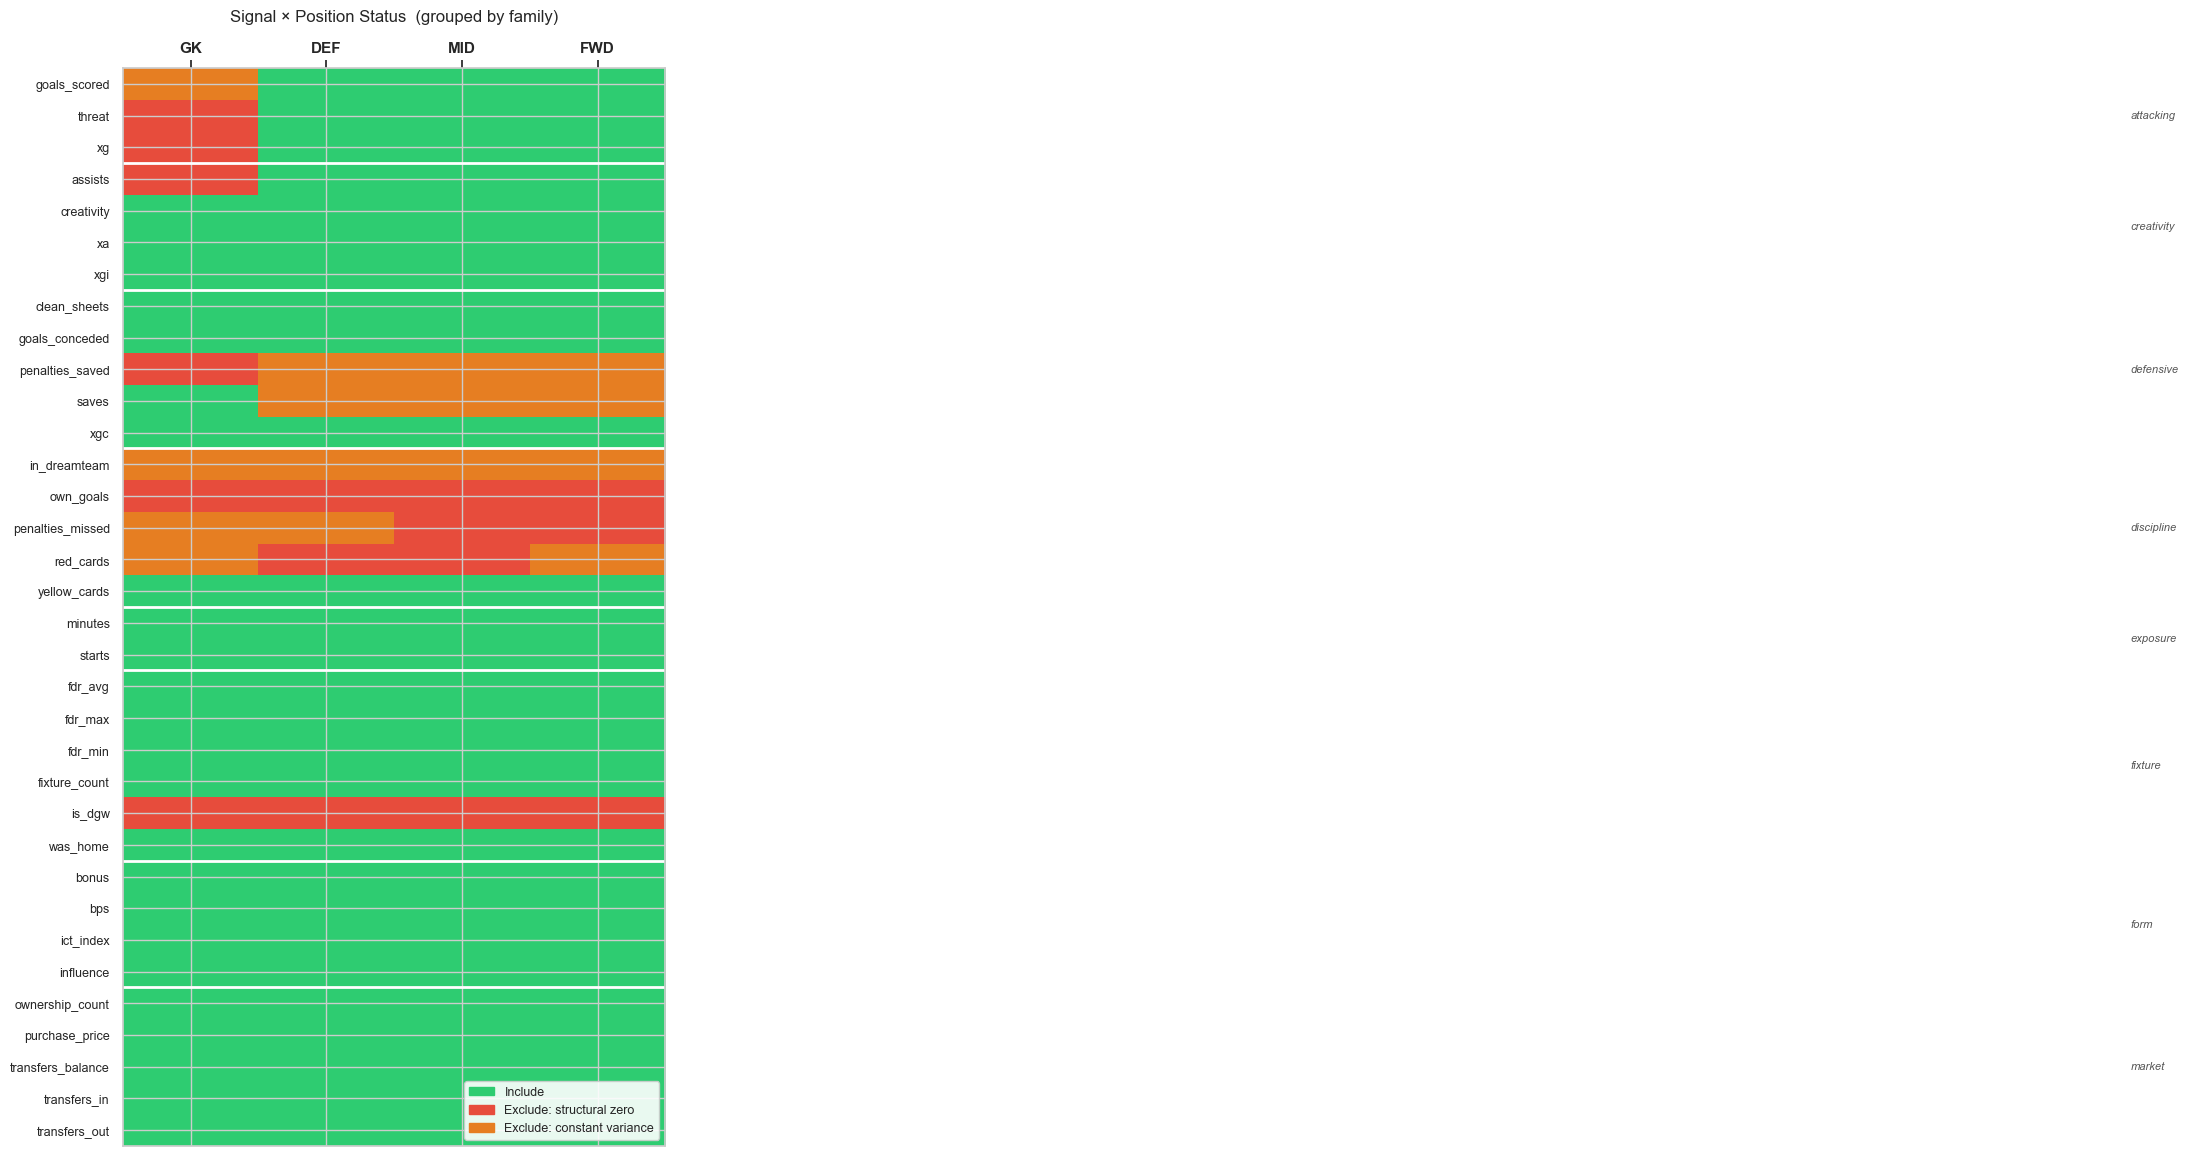

Saved: eda_02_viz_status_heatmap.png


In [10]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

FAMILY_ORDER = ["attacking", "creativity", "defensive", "discipline", "exposure", "fixture", "form", "market"]
POSITION_ORDER = ["GK", "DEF", "MID", "FWD"]
POSITION_LABEL = {1: "GK", 2: "DEF", 3: "MID", 4: "FWD"}

STATUS_COLOR = {
    "INCLUDE": "#2ecc71",
    "EXCLUDE:structural_zero": "#e74c3c",
    "EXCLUDE:constant_variance": "#e67e22",
}
STATUS_LABEL = {
    "INCLUDE": "Include",
    "EXCLUDE:structural_zero": "Exclude: structural zero",
    "EXCLUDE:constant_variance": "Exclude: constant variance",
}

# Reload registry from disk so this cell is self-contained
reg = pd.read_csv(REGISTRY_CSV)
reg["position_label"] = reg["position"].map({"GK": "GK", "DEF": "DEF", "MID": "MID", "FWD": "FWD"})

# ── 1. Status heatmap: signal × position, grouped by family ──────────────────
fig, ax = plt.subplots(figsize=(7, 14))

# Sort signals by family then name for grouping
reg_sorted = reg.copy()
reg_sorted["family_order"] = reg_sorted["signal_family"].map({f: i for i, f in enumerate(FAMILY_ORDER)})
reg_sorted = reg_sorted.sort_values(["family_order", "signal"])
signals_ordered = reg_sorted["signal"].unique().tolist()

status_num = {"INCLUDE": 1, "EXCLUDE:structural_zero": 2, "EXCLUDE:constant_variance": 3}
pivot = reg_sorted.pivot(index="signal", columns="position", values="status").reindex(
    index=signals_ordered, columns=POSITION_ORDER
)
pivot_num = pivot.applymap(lambda s: status_num.get(s, 0))

cmap = plt.cm.colors.ListedColormap(["#2ecc71", "#e74c3c", "#e67e22"])
ax.imshow(pivot_num.values, aspect="auto", cmap=cmap, vmin=0.5, vmax=3.5, interpolation="none")

ax.set_xticks(range(len(POSITION_ORDER)))
ax.set_xticklabels(POSITION_ORDER, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(signals_ordered)))
ax.set_yticklabels(signals_ordered, fontsize=9)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")

# Family group dividers + labels
prev_family = None
family_starts = {}
for i, sig in enumerate(signals_ordered):
    fam = reg_sorted[reg_sorted["signal"] == sig]["signal_family"].iloc[0]
    if fam != prev_family:
        if i > 0:
            ax.axhline(i - 0.5, color="white", linewidth=2)
        family_starts[fam] = i
        prev_family = fam

# Right-side family labels
family_rows = {}
for fam in FAMILY_ORDER:
    rows = [i for i, s in enumerate(signals_ordered)
            if reg_sorted[reg_sorted["signal"] == s]["signal_family"].iloc[0] == fam]
    if rows:
        family_rows[fam] = (min(rows), max(rows))

for fam, (r0, r1) in family_rows.items():
    mid = (r0 + r1) / 2
    ax.text(len(POSITION_ORDER) - 0.3, mid, fam, va="center", ha="left", fontsize=8,
            color="#555", fontstyle="italic",
            transform=ax.get_yaxis_transform())

patches = [mpatches.Patch(color=c, label=STATUS_LABEL[s]) for s, c in STATUS_COLOR.items()]
ax.legend(handles=patches, loc="lower right", fontsize=9, framealpha=0.9)
ax.set_title("Signal × Position Status  (grouped by family)", fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(FINDINGS_DIR / "eda_02_viz_status_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eda_02_viz_status_heatmap.png")

/var/folders/66/hjdps8cj0sd_nt4v35d18wzc0000gn/T/ipykernel_15586/1401936675.py:61: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/66/hjdps8cj0sd_nt4v35d18wzc0000gn/T/ipykernel_15586/1401936675.py:62: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(FINDINGS_DIR / "eda_02_viz_bubble_power.png", dpi=130, bbox_inches="tight")
/Users/safarifgisa/Documents/fpl-intelligence/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


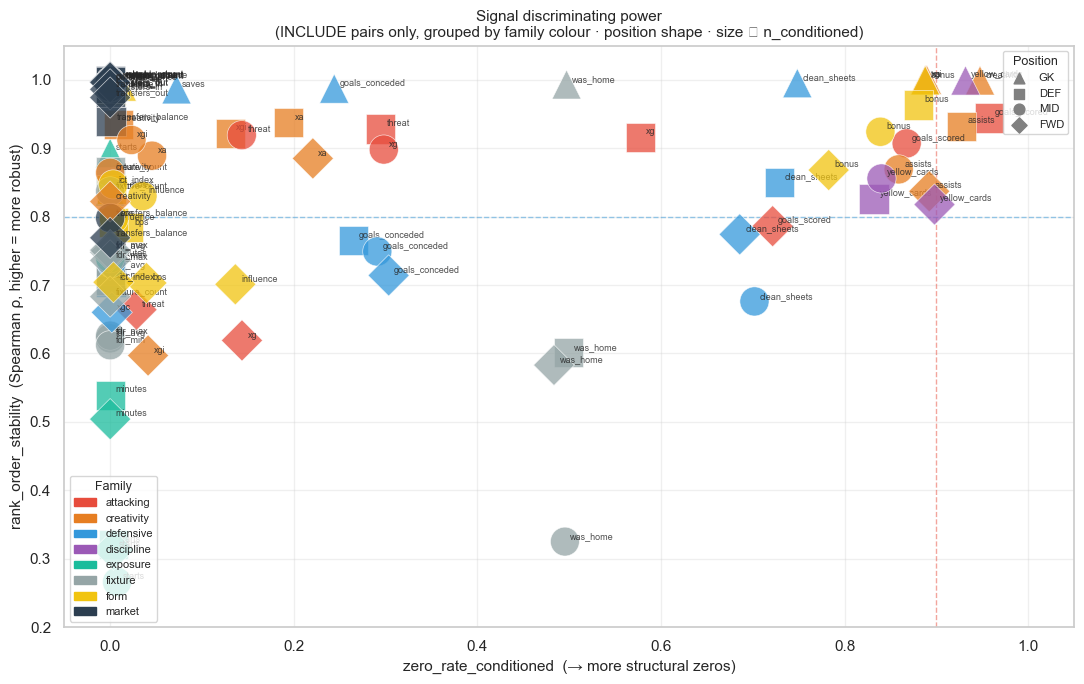

Saved: eda_02_viz_bubble_power.png


In [11]:
# ── 2. Bubble chart: zero_rate_conditioned vs rank_order_stability ───────────
FAMILY_COLORS = {
    "attacking":  "#e74c3c",
    "creativity": "#e67e22",
    "defensive":  "#3498db",
    "discipline": "#9b59b6",
    "exposure":   "#1abc9c",
    "fixture":    "#95a5a6",
    "form":       "#f1c40f",
    "market":     "#2c3e50",
}
MARKER = {"GK": "^", "DEF": "s", "MID": "o", "FWD": "D"}

inc = reg[reg["status"] == "INCLUDE"].dropna(subset=["rank_order_stability", "zero_rate_conditioned"])

fig, ax = plt.subplots(figsize=(11, 7))

for pos in POSITION_ORDER:
    sub = inc[inc["position"] == pos]
    for fam in FAMILY_ORDER:
        pts = sub[sub["signal_family"] == fam]
        if pts.empty:
            continue
        sizes = (pts["n_conditioned"] / pts["n_conditioned"].max()) * 400 + 40
        ax.scatter(
            pts["zero_rate_conditioned"],
            pts["rank_order_stability"],
            s=sizes,
            c=[FAMILY_COLORS[fam]],
            marker=MARKER[pos],
            alpha=0.75,
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
        )
        for _, row in pts.iterrows():
            ax.annotate(
                row["signal"],
                (row["zero_rate_conditioned"], row["rank_order_stability"]),
                fontsize=6.5, alpha=0.8,
                xytext=(4, 2), textcoords="offset points",
            )

ax.axvline(0.90, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.5, label="zero_rate=0.90 (high risk)")
ax.axhline(0.80, color="#3498db", linestyle="--", linewidth=1, alpha=0.5, label="rank stability=0.80")
ax.set_xlabel("zero_rate_conditioned  (→ more structural zeros)", fontsize=11)
ax.set_ylabel("rank_order_stability  (Spearman ρ, higher = more robust)", fontsize=11)
ax.set_title("Signal discriminating power\n(INCLUDE pairs only, grouped by family colour · position shape · size ∝ n_conditioned)", fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.2, 1.05)
ax.grid(True, alpha=0.3)

family_patches = [mpatches.Patch(color=FAMILY_COLORS[f], label=f) for f in FAMILY_ORDER]
pos_handles = [
    plt.scatter([], [], marker=MARKER[p], c="grey", s=60, label=p) for p in POSITION_ORDER
]
leg1 = ax.legend(handles=family_patches, title="Family", loc="lower left", fontsize=8, title_fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=pos_handles, title="Position", loc="upper right", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(FINDINGS_DIR / "eda_02_viz_bubble_power.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eda_02_viz_bubble_power.png")

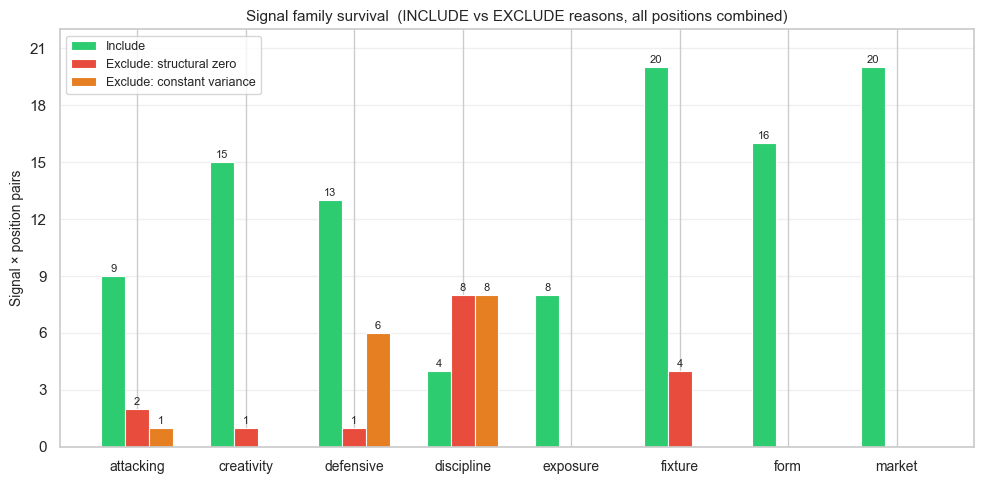

Saved: eda_02_viz_family_survival.png


In [12]:
# ── 3. Family survival bar chart ─────────────────────────────────────────────
EXCLUDE_COLORS = {
    "INCLUDE": "#2ecc71",
    "EXCLUDE:structural_zero": "#e74c3c",
    "EXCLUDE:constant_variance": "#e67e22",
}

counts = (
    reg.groupby(["signal_family", "status"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=FAMILY_ORDER)
)
# Ensure all columns present
for col in EXCLUDE_COLORS:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[list(EXCLUDE_COLORS.keys())]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(FAMILY_ORDER))
bar_w = 0.22
offsets = [-bar_w, 0, bar_w]

for i, (status, color) in enumerate(EXCLUDE_COLORS.items()):
    vals = counts[status].values
    bars = ax.bar(x + offsets[i], vals, width=bar_w, color=color,
                  label=STATUS_LABEL[status], edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(v), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(FAMILY_ORDER, fontsize=10)
ax.set_ylabel("Signal × position pairs", fontsize=10)
ax.set_title("Signal family survival  (INCLUDE vs EXCLUDE reasons, all positions combined)", fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, counts.values.max() + 2)

plt.tight_layout()
plt.savefig(FINDINGS_DIR / "eda_02_viz_family_survival.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eda_02_viz_family_survival.png")